In [2]:
!pip install rpy2

In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
data <- read.csv("/content/train.csv")
head(data)

  PassengerId Survived Pclass
1           1        0      3
2           2        1      1
3           3        1      3
4           4        1      1
5           5        0      3
6           6        0      3
                                                 Name    Sex Age SibSp Parch
1                             Braund, Mr. Owen Harris   male  22     1     0
2 Cumings, Mrs. John Bradley (Florence Briggs Thayer) female  38     1     0
3                              Heikkinen, Miss. Laina female  26     0     0
4        Futrelle, Mrs. Jacques Heath (Lily May Peel) female  35     1     0
5                            Allen, Mr. William Henry   male  35     0     0
6                                    Moran, Mr. James   male  NA     0     0
            Ticket    Fare Cabin Embarked
1        A/5 21171  7.2500              S
2         PC 17599 71.2833   C85        C
3 STON/O2. 3101282  7.9250              S
4           113803 53.1000  C123        S
5           373450  8.0500              S

In [5]:
%%R

str(data)

summary(data)

dim(data)

names(data)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...
 [1] "PassengerId" "Survived"    "Pclass"      "Name"        "Sex"        
 [6] "Age"         "SibSp"       "Parch"       "Ticket"      "Fare"       
[11] "Cabin"       "Embarked"   


In [48]:
%%R

missing_values <- colSums(is.na(data))

print(missing_values)

total_missing <- sum(is.na(data))

print(total_missing)

    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 
[1] 0


In [9]:
%%R

total_missing <- sum(is.na(data))

print(total_missing)

[1] 177


In [10]:
%%R

median_age <- median(data$Age, na.rm = TRUE)

print(median_age)

[1] 28


In [49]:
%%R

median_age <- median(data$Age, na.rm = TRUE)

print(median_age)

data$Age[is.na(data$Age)] <- median_age

colSums(is.na(data))

[1] 28
    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 


In [12]:
%%R

duplicate_count <- sum(duplicated(data))

print(duplicate_count)

[1] 0


In [13]:
%%R


data[duplicated(data), ]

 [1] PassengerId Survived    Pclass      Name        Sex         Age        
 [7] SibSp       Parch       Ticket      Fare        Cabin       Embarked   
<0 rows> (or 0-length row.names)


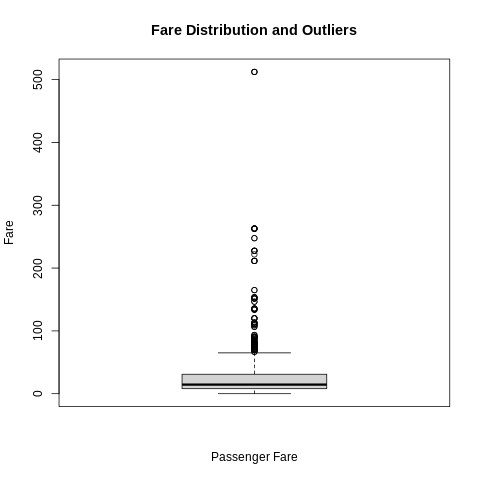

In [14]:
%%R

boxplot(
  data$Fare,
  main = "Fare Distribution and Outliers",
  ylab = "Fare",
  xlab = "Passenger Fare"
)

In [15]:
%%R

Q1 <- quantile(data$Fare, 0.25, na.rm = TRUE)
Q3 <- quantile(data$Fare, 0.75, na.rm = TRUE)

IQR_value <- IQR(data$Fare, na.rm = TRUE)

lower_limit <- Q1 - 1.5 * IQR_value
upper_limit <- Q3 + 1.5 * IQR_value

print(Q1)
print(Q3)
print(IQR_value)
print(lower_limit)
print(upper_limit)

   25% 
7.9104 
75% 
 31 
[1] 23.0896
    25% 
-26.724 
    75% 
65.6344 


In [16]:
%%R

outliers <- data$Fare[
  data$Fare < lower_limit |
  data$Fare > upper_limit
]

print(length(outliers))

[1] 116


In [18]:
%%R

data$Fare_capped <- data$Fare

data$Fare_capped[data$Fare_capped > upper_limit] <- upper_limit

data$Fare_capped[data$Fare_capped < lower_limit] <- lower_limit

summary(data$Fare_capped)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    7.91   14.45   24.05   31.00   65.63 


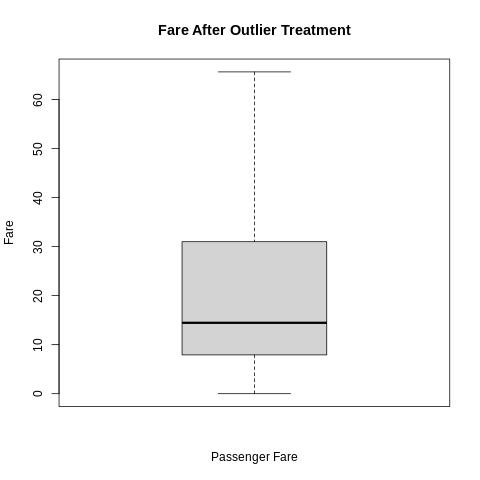

In [19]:
%%R

boxplot(
  data$Fare_capped,
  main = "Fare After Outlier Treatment",
  ylab = "Fare",
  xlab = "Passenger Fare"
)

In [20]:
%%R

min_max <- function(x) {
  (x - min(x, na.rm = TRUE)) /
    (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))
}

In [21]:
%%R

data$Age_normalized <- min_max(data$Age)

data$Fare_normalized <- min_max(data$Fare_capped)

head(data[, c(
  "Age",
  "Age_normalized",
  "Fare_capped",
  "Fare_normalized"
)])

  Age Age_normalized Fare_capped Fare_normalized
1  22      0.2711737      7.2500       0.1104604
2  38      0.4722292     65.6344       1.0000000
3  26      0.3214375      7.9250       0.1207446
4  35      0.4345313     53.1000       0.8090270
5  35      0.4345313      8.0500       0.1226491
6  28      0.3465695      8.4583       0.1288699


In [22]:
%%R

summary(data$Age_normalized)
summary(data$Fare_normalized)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.1205  0.2202  0.3664  0.4723  1.0000 


In [23]:
%%R

data$Sex_encoded <- ifelse(
  data$Sex == "male",
  1,
  0
)

head(data[, c("Sex", "Sex_encoded")])

     Sex Sex_encoded
1   male           1
2 female           0
3 female           0
4 female           0
5   male           1
6   male           1


In [24]:
%%R

embarked_encoded <- model.matrix(
  ~ Embarked - 1,
  data = data
)


head(embarked_encoded)

  Embarked EmbarkedC EmbarkedQ EmbarkedS
1        0         0         0         1
2        0         1         0         0
3        0         0         0         1
4        0         0         0         1
5        0         0         0         1
6        0         0         1         0


In [25]:
%%R

summary(data)

  PassengerId       Survived          Pclass             Name    
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000   Length   :891  
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000   N.unique :891  
 Median :446.0   Median :0.0000   Median :3.000   N.blank  :  0  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309   Min.nchar: 12  
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000   Max.nchar: 82  
 Max.   :891.0   Max.   :1.0000   Max.   :3.000                  
        Sex           Age            SibSp           Parch       
 Length   :891   Min.   : 0.42   Min.   :0.000   Min.   :0.0000  
 N.unique :  2   1st Qu.:22.00   1st Qu.:0.000   1st Qu.:0.0000  
 N.blank  :  0   Median :28.00   Median :0.000   Median :0.0000  
 Min.nchar:  4   Mean   :29.36   Mean   :0.523   Mean   :0.3816  
 Max.nchar:  6   3rd Qu.:35.00   3rd Qu.:1.000   3rd Qu.:0.0000  
                 Max.   :80.00   Max.   :8.000   Max.   :6.0000  
       Ticket         Fare              Cabin          Embarked  
 Length   

In [26]:
%%R

summary(
  data[, c(
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Fare_capped"
  )]
)

      Age            SibSp           Parch             Fare       
 Min.   : 0.42   Min.   :0.000   Min.   :0.0000   Min.   :  0.00  
 1st Qu.:22.00   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:  7.91  
 Median :28.00   Median :0.000   Median :0.0000   Median : 14.45  
 Mean   :29.36   Mean   :0.523   Mean   :0.3816   Mean   : 32.20  
 3rd Qu.:35.00   3rd Qu.:1.000   3rd Qu.:0.0000   3rd Qu.: 31.00  
 Max.   :80.00   Max.   :8.000   Max.   :6.0000   Max.   :512.33  
  Fare_capped   
 Min.   : 0.00  
 1st Qu.: 7.91  
 Median :14.45  
 Mean   :24.05  
 3rd Qu.:31.00  
 Max.   :65.63  


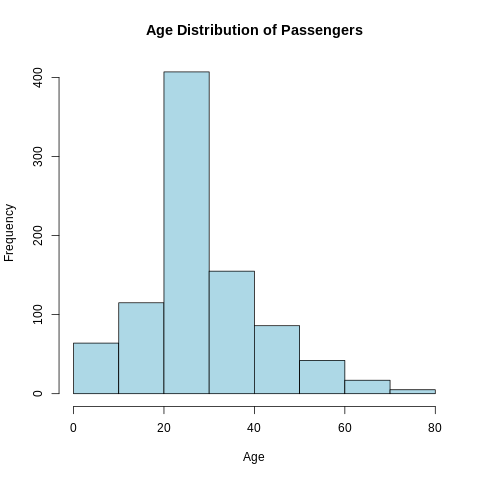

In [27]:
%%R

hist(
  data$Age,
  main = "Age Distribution of Passengers",
  xlab = "Age",
  ylab = "Frequency",
  col = "lightblue",
  border = "black"
)

In [28]:
%%R

gender_survival <- table(
  data$Sex,
  data$Survived
)

print(gender_survival)

        
           0   1
  female  81 233
  male   468 109


In [29]:
%%R

gender_survival_rate <- prop.table(
  table(data$Sex, data$Survived),
  margin = 1
) * 100

print(round(gender_survival_rate, 2))

        
             0     1
  female 25.80 74.20
  male   81.11 18.89


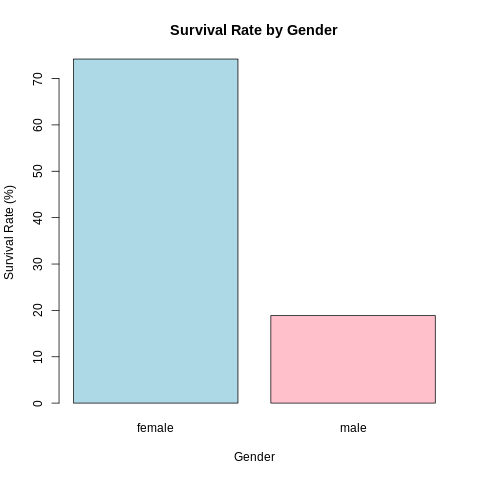

In [30]:
%%R

barplot(
  gender_survival_rate[, "1"],
  main = "Survival Rate by Gender",
  xlab = "Gender",
  ylab = "Survival Rate (%)",
  col = c("lightblue", "pink")
)

In [32]:
%%R

class_survival_rate <- prop.table(
  table(data$Pclass, data$Survived),
  margin = 1
) * 100

print(round(class_survival_rate, 2))

   
        0     1
  1 37.04 62.96
  2 52.72 47.28
  3 75.76 24.24


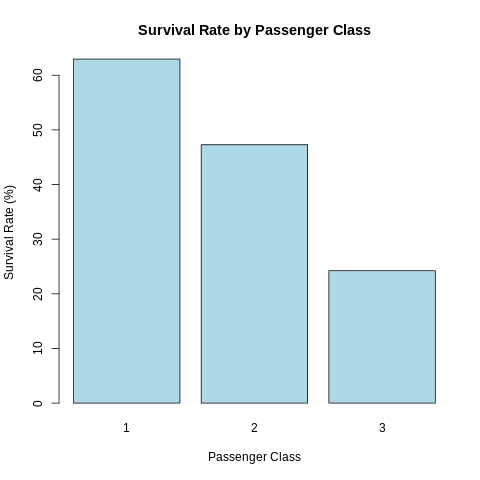

In [33]:
%%R

barplot(
  class_survival_rate[, "1"],
  main = "Survival Rate by Passenger Class",
  xlab = "Passenger Class",
  ylab = "Survival Rate (%)",
  col = "lightblue"
)

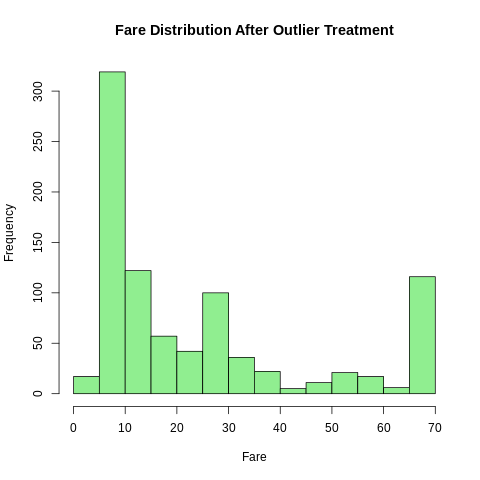

In [34]:
%%R

hist(
  data$Fare_capped,
  main = "Fare Distribution After Outlier Treatment",
  xlab = "Fare",
  ylab = "Frequency",
  col = "lightgreen",
  border = "black"
)

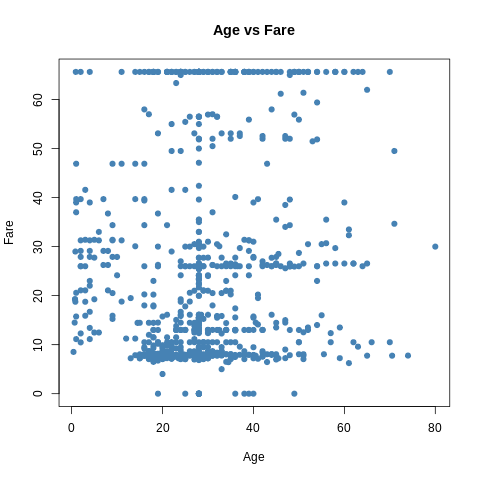

In [35]:
%%R

plot(
  data$Age,
  data$Fare_capped,
  main = "Age vs Fare",
  xlab = "Age",
  ylab = "Fare",
  pch = 19,
  col = "steelblue"
)

In [36]:
%%R

numeric_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(round(cor_matrix, 3))

            Survived Pclass    Age  SibSp  Parch Fare_capped
Survived       1.000 -0.338 -0.065 -0.035  0.082       0.317
Pclass        -0.338  1.000 -0.340  0.083  0.018      -0.715
Age           -0.065 -0.340  1.000 -0.233 -0.172       0.144
SibSp         -0.035  0.083 -0.233  1.000  0.415       0.332
Parch          0.082  0.018 -0.172  0.415  1.000       0.293
Fare_capped    0.317 -0.715  0.144  0.332  0.293       1.000


In [37]:
%%R

survival_correlations <- cor_matrix[, "Survived"]

print(round(survival_correlations, 3))

   Survived      Pclass         Age       SibSp       Parch Fare_capped 
      1.000      -0.338      -0.065      -0.035       0.082       0.317 


In [38]:
%%R

numeric_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(round(cor_matrix, 3))

            Survived Pclass    Age  SibSp  Parch Fare_capped
Survived       1.000 -0.338 -0.065 -0.035  0.082       0.317
Pclass        -0.338  1.000 -0.340  0.083  0.018      -0.715
Age           -0.065 -0.340  1.000 -0.233 -0.172       0.144
SibSp         -0.035  0.083 -0.233  1.000  0.415       0.332
Parch          0.082  0.018 -0.172  0.415  1.000       0.293
Fare_capped    0.317 -0.715  0.144  0.332  0.293       1.000


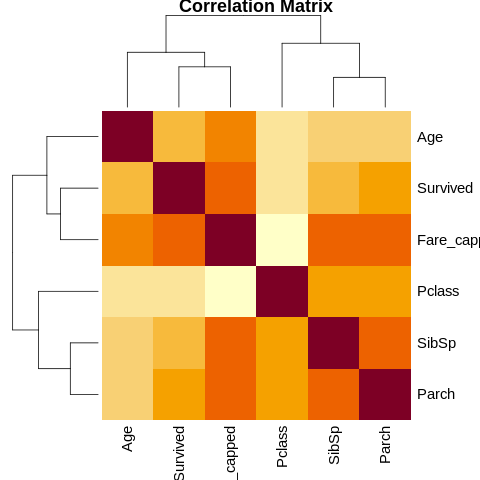

In [43]:
%%R

heatmap(
  cor_matrix,
  main = "Correlation Matrix",
  symm = TRUE
)

In [44]:
%%R

print(round(cor_matrix[, "Survived"], 3))

   Survived      Pclass         Age       SibSp       Parch Fare_capped 
      1.000      -0.338      -0.065      -0.035       0.082       0.317 


In [45]:
%%R


cat("Missing values after cleaning:\n")
print(colSums(is.na(data)))

cat("\nFinal dataset dimensions:\n")
print(dim(data))

cat("\nFinal dataset structure:\n")
str(data)

Missing values after cleaning:
    PassengerId        Survived          Pclass            Name             Sex 
              0               0               0               0               0 
            Age           SibSp           Parch          Ticket            Fare 
              0               0               0               0               0 
          Cabin        Embarked     Fare_capped  Age_normalized Fare_normalized 
              0               0               0               0               0 
    Sex_encoded 
              0 

Final dataset dimensions:
[1] 891  16

Final dataset structure:
'data.frame':	891 obs. of  16 variables:
 $ PassengerId    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived       : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass         : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name           : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        

In [46]:
%%R

write.csv(
  data,
  "/content/Titanic_Cleaned.csv",
  row.names = FALSE
)

cat("Cleaned dataset saved successfully.\n")

Cleaned dataset saved successfully.


In [47]:
%%R

cat("===== FINAL ANALYSIS SUMMARY =====\n")
cat("Original number of rows: 891\n")
cat("Final number of rows:", nrow(data), "\n")
cat("Missing Age values after cleaning:",
    sum(is.na(data$Age)), "\n")
cat("Duplicate rows:", sum(duplicated(data)), "\n")
cat("Fare outliers detected:", length(outliers), "\n")
cat("Fare upper outlier limit:", round(upper_limit, 4), "\n")
cat("Mean Age:", round(mean(data$Age), 2), "\n")
cat("Mean Fare before treatment:", round(mean(data$Fare), 2), "\n")
cat("Mean Fare after treatment:", round(mean(data$Fare_capped), 2), "\n")
cat("Overall survival rate:",
    round(mean(data$Survived) * 100, 2), "%\n")

===== FINAL ANALYSIS SUMMARY =====
Original number of rows: 891
Final number of rows: 891 
Missing Age values after cleaning: 0 
Duplicate rows: 0 
Fare outliers detected: 116 
Fare upper outlier limit: 65.6344 
Mean Age: 29.36 
Mean Fare before treatment: 32.2 
Mean Fare after treatment: 24.05 
Overall survival rate: 38.38 %


In [52]:
%%R

dim(data)
head(data)

  PassengerId Survived Pclass
1           1        0      3
2           2        1      1
3           3        1      3
4           4        1      1
5           5        0      3
6           6        0      3
                                                 Name    Sex Age SibSp Parch
1                             Braund, Mr. Owen Harris   male  22     1     0
2 Cumings, Mrs. John Bradley (Florence Briggs Thayer) female  38     1     0
3                              Heikkinen, Miss. Laina female  26     0     0
4        Futrelle, Mrs. Jacques Heath (Lily May Peel) female  35     1     0
5                            Allen, Mr. William Henry   male  35     0     0
6                                    Moran, Mr. James   male  28     0     0
            Ticket    Fare Cabin Embarked Fare_capped Age_normalized
1        A/5 21171  7.2500              S      7.2500      0.2711737
2         PC 17599 71.2833   C85        C     65.6344      0.4722292
3 STON/O2. 3101282  7.9250              S   

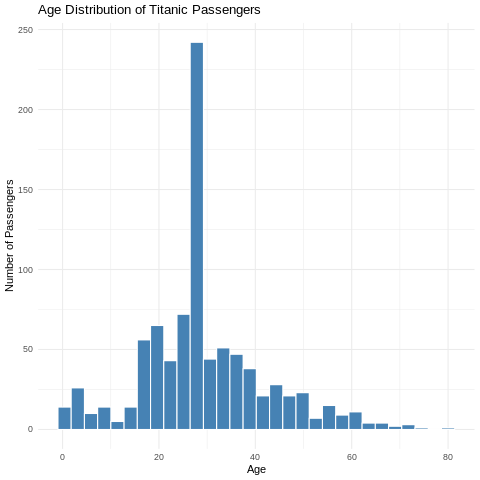

In [53]:
%%R

library(ggplot2)

ggplot(data, aes(x = Age)) +
  geom_histogram(
    bins = 30,
    fill = "steelblue",
    color = "white"
  ) +
  labs(
    title = "Age Distribution of Titanic Passengers",
    x = "Age",
    y = "Number of Passengers"
  ) +
  theme_minimal()

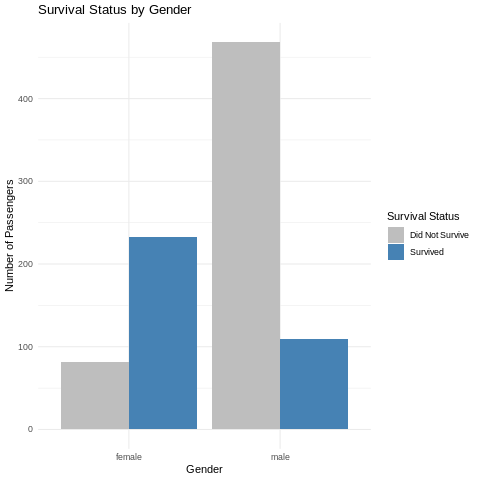

In [54]:
%%R

ggplot(data, aes(x = Sex, fill = factor(Survived))) +
  geom_bar(position = "dodge") +
  labs(
    title = "Survival Status by Gender",
    x = "Gender",
    y = "Number of Passengers",
    fill = "Survival Status"
  ) +
  scale_fill_manual(
    values = c("0" = "gray", "1" = "steelblue"),
    labels = c(
      "0" = "Did Not Survive",
      "1" = "Survived"
    )
  ) +
  theme_minimal()


In [56]:
%%R

class_rate <- aggregate(
  Survived ~ Pclass,
  data = data,
  FUN = mean
)

class_rate$Survival_Rate <- class_rate$Survived * 100

print(class_rate)

  Pclass  Survived Survival_Rate
1      1 0.6296296      62.96296
2      2 0.4728261      47.28261
3      3 0.2423625      24.23625


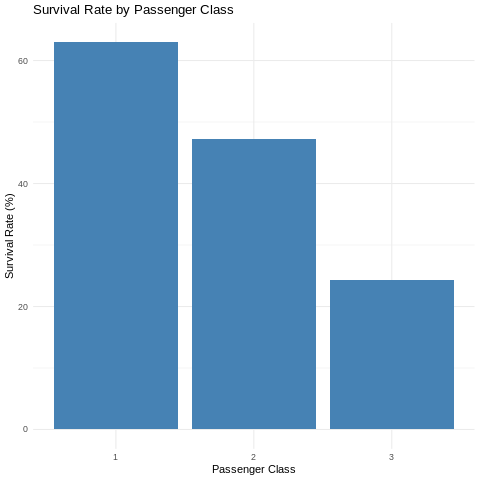

In [57]:
%%R

library(ggplot2)

ggplot(
  class_rate,
  aes(
    x = factor(Pclass),
    y = Survival_Rate
  )
) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Survival Rate by Passenger Class",
    x = "Passenger Class",
    y = "Survival Rate (%)"
  ) +
  theme_minimal()

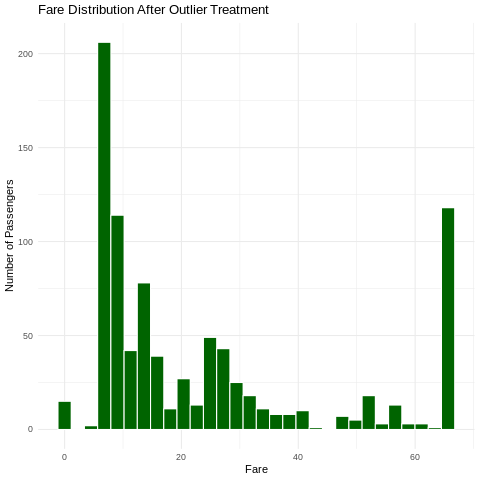

In [58]:
%%R

ggplot(data, aes(x = Fare_capped)) +
  geom_histogram(
    bins = 30,
    fill = "darkgreen",
    color = "white"
  ) +
  labs(
    title = "Fare Distribution After Outlier Treatment",
    x = "Fare",
    y = "Number of Passengers"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


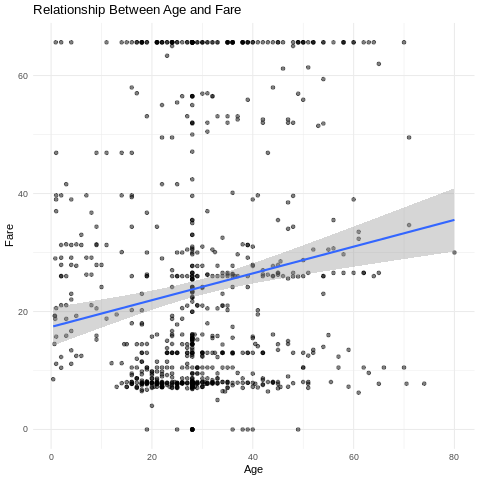

In [59]:
%%R

ggplot(
  data,
  aes(
    x = Age,
    y = Fare_capped
  )
) +
  geom_point(alpha = 0.5) +
  geom_smooth(
    method = "lm",
    se = TRUE
  ) +
  labs(
    title = "Relationship Between Age and Fare",
    x = "Age",
    y = "Fare"
  ) +
  theme_minimal()


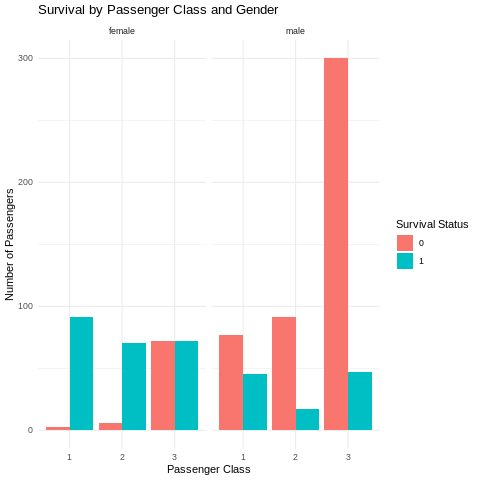

In [60]:
%%R

ggplot(
  data,
  aes(
    x = factor(Pclass),
    fill = factor(Survived)
  )
) +
  geom_bar(position = "dodge") +
  facet_wrap(~Sex) +
  labs(
    title = "Survival by Passenger Class and Gender",
    x = "Passenger Class",
    y = "Number of Passengers",
    fill = "Survival Status"
  ) +
  theme_minimal()

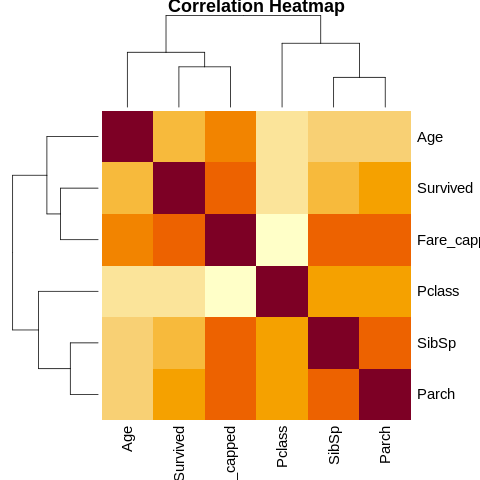

In [61]:
%%R

cor_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  cor_data,
  use = "complete.obs"
)

heatmap(
  cor_matrix,
  main = "Correlation Heatmap",
  symm = TRUE
)

week3

In [62]:
%%R

summary(data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)])

    Survived          Pclass           Age            SibSp      
 Min.   :0.0000   Min.   :1.000   Min.   : 0.42   Min.   :0.000  
 1st Qu.:0.0000   1st Qu.:2.000   1st Qu.:22.00   1st Qu.:0.000  
 Median :0.0000   Median :3.000   Median :28.00   Median :0.000  
 Mean   :0.3838   Mean   :2.309   Mean   :29.36   Mean   :0.523  
 3rd Qu.:1.0000   3rd Qu.:3.000   3rd Qu.:35.00   3rd Qu.:1.000  
 Max.   :1.0000   Max.   :3.000   Max.   :80.00   Max.   :8.000  
     Parch         Fare_capped   
 Min.   :0.0000   Min.   : 0.00  
 1st Qu.:0.0000   1st Qu.: 7.91  
 Median :0.0000   Median :14.45  
 Mean   :0.3816   Mean   :24.05  
 3rd Qu.:0.0000   3rd Qu.:31.00  
 Max.   :6.0000   Max.   :65.63  


In [63]:
%%R

cat("Mean Age:", mean(data$Age, na.rm = TRUE), "\n")
cat("Median Age:", median(data$Age, na.rm = TRUE), "\n")
cat("Mean Fare:", mean(data$Fare_capped, na.rm = TRUE), "\n")
cat("Median Fare:", median(data$Fare_capped, na.rm = TRUE), "\n")

Mean Age: 29.36158 
Median Age: 28 
Mean Fare: 24.04681 
Median Fare: 14.4542 


In [64]:
%%R

cor_data <- data[, c(
  "Survived",
  "Pclass",
  "Age",
  "SibSp",
  "Parch",
  "Fare_capped"
)]

cor_matrix <- cor(
  cor_data,
  use = "complete.obs"
)

print(round(cor_matrix, 3))

            Survived Pclass    Age  SibSp  Parch Fare_capped
Survived       1.000 -0.338 -0.065 -0.035  0.082       0.317
Pclass        -0.338  1.000 -0.340  0.083  0.018      -0.715
Age           -0.065 -0.340  1.000 -0.233 -0.172       0.144
SibSp         -0.035  0.083 -0.233  1.000  0.415       0.332
Parch          0.082  0.018 -0.172  0.415  1.000       0.293
Fare_capped    0.317 -0.715  0.144  0.332  0.293       1.000


In [65]:
%%R

set.seed(123)

age_sample <- sample(
  data$Age,
  min(500, length(data$Age))
)

shapiro_result <- shapiro.test(age_sample)

print(shapiro_result)


	Shapiro-Wilk normality test

data:  age_sample
W = 0.9519, p-value = 1.102e-11



In [66]:
%%R

gender_table <- table(
  data$Sex,
  data$Survived
)

print(gender_table)

chi_gender <- chisq.test(gender_table)

print(chi_gender)

        
           0   1
  female  81 233
  male   468 109

	Pearson's Chi-squared test with Yates' continuity correction

data:  gender_table
X-squared = 260.72, df = 1, p-value < 2.2e-16



In [67]:
%%R

set.seed(123)

n <- nrow(data)

train_index <- sample(
  1:n,
  size = 0.8 * n
)

train_data <- data[train_index, ]
test_data <- data[-train_index, ]

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows:", nrow(test_data), "\n")

Training rows: 712 
Testing rows: 179 


In [68]:
%%R

model <- glm(
  Survived ~ Pclass + Sex + Age + SibSp + Parch + Fare_capped,
  data = train_data,
  family = binomial
)

summary(model)


Call:
glm(formula = Survived ~ Pclass + Sex + Age + SibSp + Parch + 
    Fare_capped, family = binomial, data = train_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.194608   0.710474   5.904 3.55e-09 ***
Pclass      -0.840734   0.193500  -4.345 1.39e-05 ***
Sexmale     -2.826916   0.224560 -12.589  < 2e-16 ***
Age         -0.038801   0.008891  -4.364 1.28e-05 ***
SibSp       -0.461289   0.134326  -3.434 0.000595 ***
Parch       -0.168789   0.129978  -1.299 0.194082    
Fare_capped  0.015639   0.008479   1.845 0.065103 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 947.98  on 711  degrees of freedom
Residual deviance: 630.50  on 705  degrees of freedom
AIC: 644.5

Number of Fisher Scoring iterations: 5



In [69]:
%%R

probabilities <- predict(
  model,
  newdata = test_data,
  type = "response"
)

predictions <- ifelse(
  probabilities >= 0.5,
  1,
  0
)

print(head(probabilities))
print(head(predictions))

        1         3         7        12        15        18 
0.0865876 0.6873002 0.3192546 0.8203396 0.7776509 0.2320293 
 1  3  7 12 15 18 
 0  1  0  1  1  0 


In [70]:
%%R

actual <- test_data$Survived

confusion_matrix <- table(
  Actual = actual,
  Predicted = predictions
)

print(confusion_matrix)

      Predicted
Actual  0  1
     0 96 14
     1 24 45


In [71]:
%%R

TN <- confusion_matrix[1,1]
FP <- confusion_matrix[1,2]
FN <- confusion_matrix[2,1]
TP <- confusion_matrix[2,2]

accuracy <- (TP + TN) / (TP + TN + FP + FN)

precision <- TP / (TP + FP)

recall <- TP / (TP + FN)

f1_score <- 2 * (precision * recall) / (precision + recall)

cat("Accuracy :", round(accuracy, 4), "\n")
cat("Precision:", round(precision, 4), "\n")
cat("Recall   :", round(recall, 4), "\n")
cat("F1 Score :", round(f1_score, 4), "\n")

Accuracy : 0.7877 
Precision: 0.7627 
Recall   : 0.6522 
F1 Score : 0.7031 


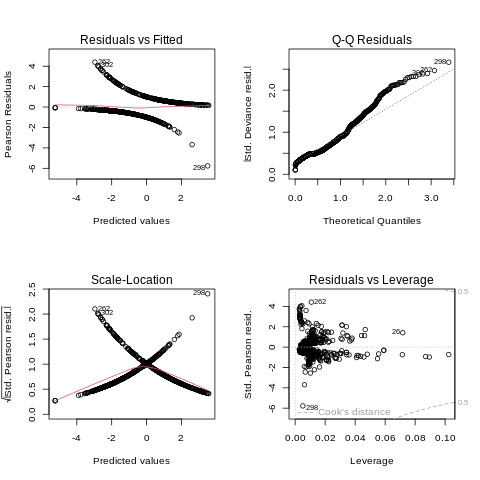

In [72]:
%%R

par(mfrow = c(2, 2))

plot(model)

In [73]:
%%R

set.seed(123)

k <- 5

folds <- sample(
  rep(1:k, length.out = nrow(data))
)

cv_accuracy <- numeric(k)

for (i in 1:k) {

  cv_train <- data[folds != i, ]
  cv_test <- data[folds == i, ]

  cv_model <- glm(
    Survived ~ Pclass + Sex + Age + SibSp + Parch + Fare_capped,
    data = cv_train,
    family = binomial
  )

  cv_prob <- predict(
    cv_model,
    newdata = cv_test,
    type = "response"
  )

  cv_pred <- ifelse(
    cv_prob >= 0.5,
    1,
    0
  )

  cv_accuracy[i] <- mean(
    cv_pred == cv_test$Survived
  )
}

print(cv_accuracy)

cat(
  "Mean 5-Fold Cross-Validation Accuracy:",
  round(mean(cv_accuracy), 4),
  "\n"
)

[1] 0.8044693 0.7528090 0.7471910 0.7921348 0.8314607
Mean 5-Fold Cross-Validation Accuracy: 0.7856 
